In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()


df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target

In [4]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


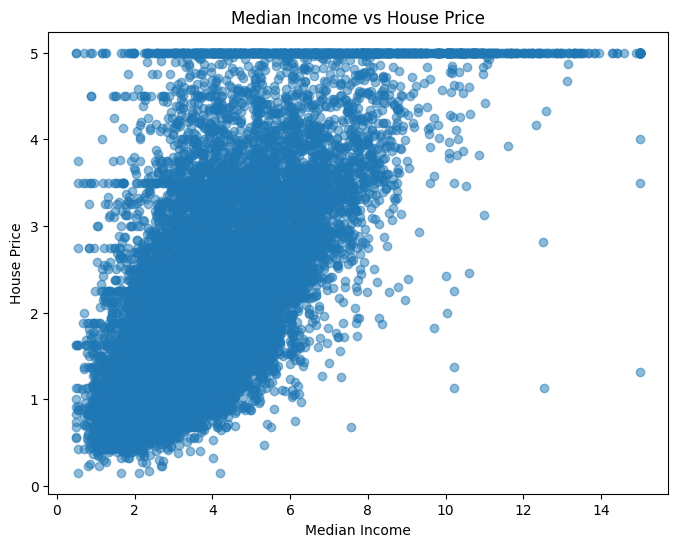

In [5]:
plt.figure(figsize=(8,6))
plt.scatter(df['MedInc'], df['Price'], alpha=0.5)
plt.xlabel('Median Income')
plt.ylabel('House Price')
plt.title('Median Income vs House Price')
plt.show()

In [6]:
df_small = df.sample(n=2000, random_state=42)

X = df_small.drop(columns='Price')
y = df_small['Price']

In [7]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import cross_val_score

In [8]:
lr = LinearRegression()
ri = Ridge()
la = Lasso()
dt = DecisionTreeRegressor()
svr = SVR()

In [9]:
estimators = [('lr',lr),('ri',ri),('la',la),('dt',dt),('svr',svr)]

In [10]:
for estimator in estimators:
  scores = cross_val_score(estimator[1],X,y,scoring='r2',cv=10)
  print(estimator[0],np.round(np.mean(scores),2))

lr 0.33
ri 0.33
la 0.26
dt 0.49
svr -0.06


In [11]:

from sklearn.ensemble import VotingRegressor

In [12]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
print("Voting Regressor",np.round(np.mean(scores),2))

Voting Regressor 0.52


In [13]:

for i in range(1,4):
    for j in range(1,4):
        for k in range(1,4):
            for l in range(1,4):
                for m in range(1,4):

                    vr = VotingRegressor(
                        estimators=estimators,
                        weights=[i, j, k, l, m]
                    )

                    scores = cross_val_score(
                        vr,
                        X,
                        y,
                        scoring='r2',
                        cv=10
                    )

                    print(
                        f"Weights=[{i},{j},{k},{l},{m}] "
                        f"R2={scores.mean():.4f}"
                    )

Weights=[1,1,1,1,1] R2=0.5230
Weights=[1,1,1,1,2] R2=0.4755
Weights=[1,1,1,1,3] R2=0.4284
Weights=[1,1,1,2,1] R2=0.5685
Weights=[1,1,1,2,2] R2=0.5315
Weights=[1,1,1,2,3] R2=0.4935
Weights=[1,1,1,3,1] R2=0.5929
Weights=[1,1,1,3,2] R2=0.5616
Weights=[1,1,1,3,3] R2=0.5308
Weights=[1,1,2,1,1] R2=0.4994
Weights=[1,1,2,1,2] R2=0.4570
Weights=[1,1,2,1,3] R2=0.4160
Weights=[1,1,2,2,1] R2=0.5495
Weights=[1,1,2,2,2] R2=0.5105
Weights=[1,1,2,2,3] R2=0.4781
Weights=[1,1,2,3,1] R2=0.5753
Weights=[1,1,2,3,2] R2=0.5509
Weights=[1,1,2,3,3] R2=0.5123
Weights=[1,1,3,1,1] R2=0.4776
Weights=[1,1,3,1,2] R2=0.4415
Weights=[1,1,3,1,3] R2=0.4045
Weights=[1,1,3,2,1] R2=0.5291
Weights=[1,1,3,2,2] R2=0.4934
Weights=[1,1,3,2,3] R2=0.4609
Weights=[1,1,3,3,1] R2=0.5594
Weights=[1,1,3,3,2] R2=0.5279
Weights=[1,1,3,3,3] R2=0.4955
Weights=[1,2,1,1,1] R2=0.5148
Weights=[1,2,1,1,2] R2=0.4876
Weights=[1,2,1,1,3] R2=0.4527
Weights=[1,2,1,2,1] R2=0.5614
Weights=[1,2,1,2,2] R2=0.5356
Weights=[1,2,1,2,3] R2=0.5053
Weights=[1

In [14]:
dt1 = DecisionTreeRegressor(max_depth=1)
dt2 = DecisionTreeRegressor(max_depth=3)
dt3 = DecisionTreeRegressor(max_depth=5)
dt4 = DecisionTreeRegressor(max_depth=7)
dt5 = DecisionTreeRegressor(max_depth=None)
     

In [15]:
estimators = [('dt1',dt1),('dt2',dt2),('dt3',dt3),('dt4',dt4),('dt5',dt5)]

In [16]:
for estimator in estimators:
  scores = cross_val_score(estimator[1],X,y,scoring='r2',cv=10)
  print(estimator[0],np.round(np.mean(scores),2))

dt1 0.26
dt2 0.49
dt3 0.57
dt4 0.57
dt5 0.48


In [17]:
vr = VotingRegressor(estimators)
scores = cross_val_score(vr,X,y,scoring='r2',cv=10)
print("Voting Regressor",np.round(np.mean(scores),2))

Voting Regressor 0.61
